In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
import os
import glob
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from scipy.integrate import cumulative_trapezoid
from scipy.special import jv
from scipy.interpolate import RegularGridInterpolator, interp1d
from astropy.cosmology import Planck18 as cosmo
from astropy import constants as con
from astropy import units as u
from scipy.integrate import trapezoid
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter
from joblib import Parallel, delayed

import BaryonForge as bfg
import pyccl as ccl

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams.update(
    {
        'text.usetex': False,
        'font.family': 'stixgeneral',
        'mathtext.fontset': 'stix',
    }
)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['image.origin'] = 'lower'
sns.set_context('talk') 
# sns.set(font_scale=1.5)
sns.set(font_scale=1.3)
sns.set_palette('colorblind')
sns.set_style('ticks')
# plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'sans'
plt.rcParams['mathtext.it'] = 'sans:italic'
plt.rcParams['mathtext.bf'] = 'sans:bold'
plt.rcParams['pdf.fonttype']=42

cmap = plt.get_cmap("rainbow_r"); colors = [cmap(i) for i in np.linspace(0, 1, 5)]

mpl.rcParams['axes.linewidth'] = 2   # thickness of the plot box
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['ytick.major.width'] = 2
mpl.rcParams['xtick.minor.width'] = 1
mpl.rcParams['ytick.minor.width'] = 1

mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['xtick.minor.size'] = 5
mpl.rcParams['ytick.minor.size'] = 5

from sensitivity_funcs import *


In [2]:
default_dict = {
    'log_Mc': 12.81, 
    'Om0': cosmo.Om0, 
    'Ob0': cosmo.Ob0, 
    'h': cosmo.H0.value/100, 
    'sigma8': 0.8111, 
    'm_nu': 0.06, 
    'w0': -1, 
    'wa': 0
}
param_names = np.array(list(default_dict.keys()))
default_values = np.array(list(default_dict.values()))

param_ranges = {
    'log_Mc': [12.5, 13.5],
    'Om0': [0.25, 0.35],
    'Ob0': [0.04, 0.06],
    'h': [0.65, 0.7],
    'sigma8': [0.7, 0.9],
    'm_nu': [0.1, 0.2],
    'w0': [-1.5, -0.5], 
    'wa': [-0.5, 0.5],
}

# all_rows = [default_values.copy()]
# for i, param in enumerate(param_names):
#     for val in param_ranges[param]:
#         row = default_values.copy()
#         row[i] = val
#         all_rows.append(row)
# df = pd.DataFrame(all_rows, columns=param_names)
# df.to_csv('forecasts/params.csv')
df = pd.read_csv('data/forecasts/precomputed_power_spectra/params.csv')
df.head()


,Unnamed: 0,log_Mc,Om0,Ob0,h,sigma8,m_nu,w0,wa
0,0,13.0,0.30966,0.04897,0.6766,0.8111,0.0,-1.0,0.0
1,1,12.5,0.30966,0.04897,0.6766,0.8111,0.0,-1.0,0.0
2,2,13.5,0.30966,0.04897,0.6766,0.8111,0.0,-1.0,0.0
3,3,13.0,0.25000,0.04897,0.6766,0.8111,0.0,-1.0,0.0
4,4,13.0,0.35000,0.04897,0.6766,0.8111,0.0,-1.0,0.0


In [3]:
redshifts = np.linspace(0, 3, 21)
k_fields = np.geomspace(1e-4, 1e6, 1000)
# mass_def=ccl.halos.massdef.MassDef200c
# c_M_relation = ccl.halos.concentration.ConcentrationDiemer15
# fft_precision = dict(padding_lo_fftlog = 1e-8, padding_hi_fftlog = 1e8, n_per_decade = 100)

# # pre-computed power spectra
# for i in tqdm(range(len(df))):
# #     os.mkdir('data/forecasts/precomputed_power_spectra/params_{}'.format(i))
#     for j in range(len(redshifts)):
#         from astropy.cosmology import Planck18 as cosmo
#         cosmo = ccl.Cosmology(Omega_c = df.Om0[i]-df.Ob0[i], 
#                               Omega_b = df.Ob0[i], 
#                               h = df.h[i], 
#                               sigma8 = df.sigma8[i], 
#                               m_nu = df.m_nu[i],
#                               w0 = df.w0[i],
#                               wa = df.wa[i],
#                               n_s = 0.9665, 
#                               matter_power_spectrum='linear', 
#                               extra_parameters={"camb": {"dark_energy_model": 'ppf'}}
#                              )
#         rho  = ccl.rho_x(cosmo, 1/(1+redshifts[j]), 'matter', is_comoving = True)
        
#         par = dict(theta_ej=3.5, theta_co=0.1, M_c=(10**df.log_Mc[i])/df.h[i], mu_beta=1, 
#                    eta=0.2, eta_delta=0.2, tau=-1.5, tau_delta=0, A=0.055/2, 
#                    M1=2.5e11/df.h[i], epsilon_h=0.015, a=0.3, n=2, epsilon=4, p=0.3, 
#                    q=0.707, gamma=2.5, delta=7)
        
#         DMO = bfg.Profiles.Schneider19.DarkMatter(**par, r_min_int=1e-3, r_max_int=1e2, r_steps=500, mass_def=mass_def, c_M_relation=c_M_relation)
#         GAS = bfg.Profiles.Schneider19.Gas(**par, r_min_int=1e-3, r_max_int=1e2, r_steps=500, mass_def=mass_def, c_M_relation=c_M_relation)
#         STR = bfg.Profiles.Schneider19.Stars(**par, r_min_int=1e-6, r_max_int=5, r_steps=500, mass_def=mass_def, c_M_relation=c_M_relation)
#         CLM = bfg.Profiles.Schneider19.CollisionlessMatter(**par, max_iter=2, reltol=5e-2, r_steps=500, mass_def=mass_def, c_M_relation=c_M_relation)
#         DMB = bfg.Profiles.Schneider19.DarkMatterBaryon(**par,
#                                                         gas=GAS, stars=STR, collisionlessmatter=CLM, darkmatter=DMO,
#                                                         twohalo=bfg.Profiles.misc.Zeros(), 
#                                                         r_steps=500, mass_def=mass_def, c_M_relation=c_M_relation)    
#         DMB = DMB / rho
#         GAS = GAS / (rho*df.Ob0[i]/df.Om0[i])
#         for p in [DMB, GAS]:
#             p.update_precision_fftlog(**fft_precision)

#         HMC  = HMCalculator_NoCorrection(mass_function = 'Tinker08', halo_bias = 'Tinker10', 
#                                          mass_def = ccl.halos.massdef.MassDef200c, 
#                                          log10M_min = 6, log10M_max = 15, nM = 100)
        
#         P_gm = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo, HMC, k_fields, 1/(1+redshifts[j]), GAS, prof2=DMB)
#         np.save('data/forecasts/precomputed_power_spectra/params_{}/P_gm_z={}.npy'.format(i, round(redshifts[j], 2)), P_gm)
        
#         P_gg = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo, HMC, k_fields, 1/(1+redshifts[j]), GAS)
#         np.save('data/forecasts/precomputed_power_spectra/params_{}/P_gg_z={}.npy'.format(i, round(redshifts[j], 2)), P_gg)

#         P_mm = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo, HMC, k_fields, 1/(1+redshifts[j]), DMB)
#         np.save('data/forecasts/precomputed_power_spectra/params_{}/P_mm_z={}.npy'.format(i, round(redshifts[j], 2)), P_mm)
        


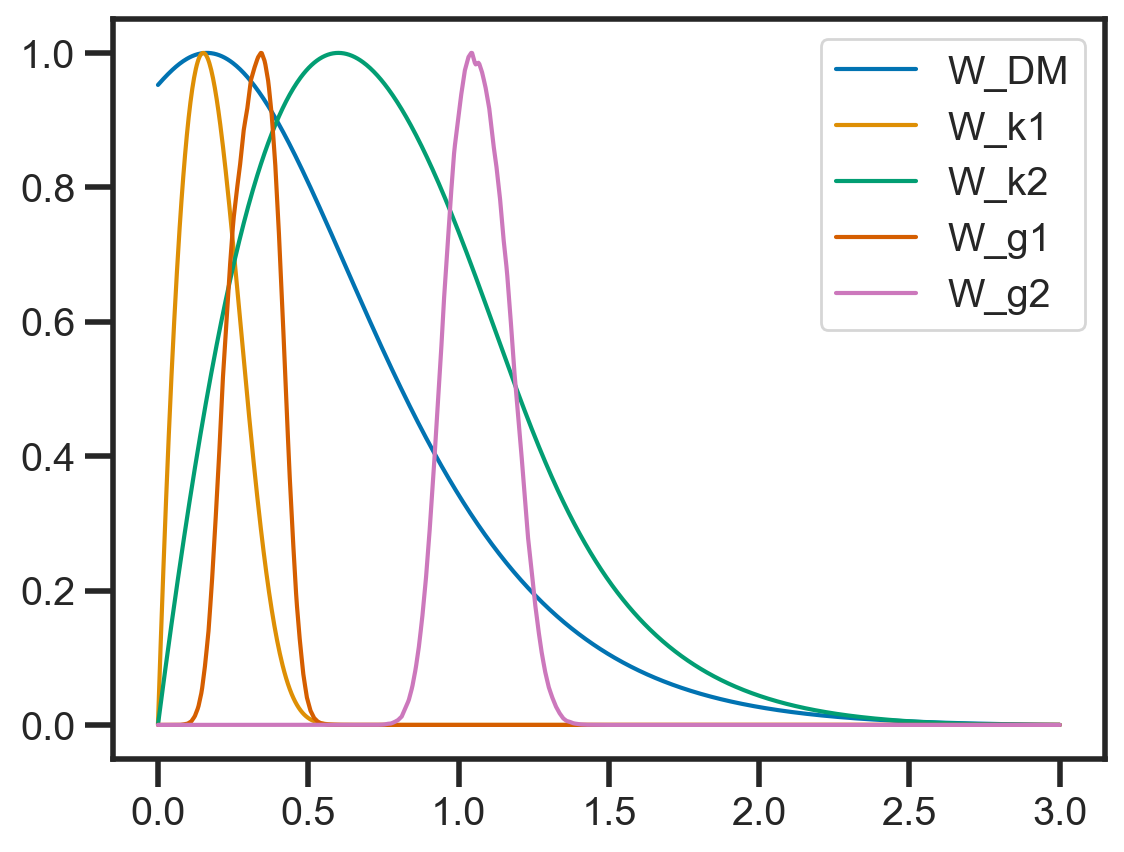

In [4]:
nz_file_k = 'data/forecasts/source_LSSTY1.nz'
nz_file_g = 'data/forecasts/lens_LSSTY1.nz'
zbin_k_idx1, zbin_k_idx2 = 1, 5
zbin_g_idx1, zbin_g_idx2 = 1, 5
lmin, lmax = 1, 10000
zmin, zmax = 0.0001, 3
n2d_mean_frb=0.00014
n2d_mean_g1=3.592707
n2d_mean_g2=2.252406

cosmo_calc = CosmologyCalculator(H0_kms_per_Mpc=default_dict["h"]*100, 
                                 Ob0=default_dict["Ob0"], 
                                 Om0=default_dict["Om0"], 
                                 sigma8=default_dict["sigma8"], 
                                 m_nu=default_dict["m_nu"], 
                                 w0=default_dict["w0"], 
                                 wa=default_dict["wa"])

src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
                              zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_k_idx1, zbin_k_idx2=zbin_k_idx2, 
                              zbin_g_idx1=zbin_g_idx1, zbin_g_idx2=zbin_g_idx2, 
                              n2d_mean_frb=n2d_mean_frb, n2d_mean_g1=n2d_mean_g1, n2d_mean_g2=n2d_mean_g2)

plt.plot(src_dist.z_grid, (src_dist.W_DM_wt*c/src_dist.Hz)/np.max(src_dist.W_DM_wt*c/src_dist.Hz), label="W_DM")

plt.plot(src_dist.z_grid, (src_dist.W_k_wt1*c/src_dist.Hz)/np.max(src_dist.W_k_wt1*c/src_dist.Hz), label="W_k1")
plt.plot(src_dist.z_grid, (src_dist.W_k_wt2*c/src_dist.Hz)/np.max(src_dist.W_k_wt2*c/src_dist.Hz), label="W_k2")

plt.plot(src_dist.z_grid, (src_dist.W_g_wt1*c/src_dist.Hz)/np.max(src_dist.W_g_wt1*c/src_dist.Hz), label="W_g1")
plt.plot(src_dist.z_grid, (src_dist.W_g_wt2*c/src_dist.Hz)/np.max(src_dist.W_g_wt2*c/src_dist.Hz), label="W_g2")

plt.legend()


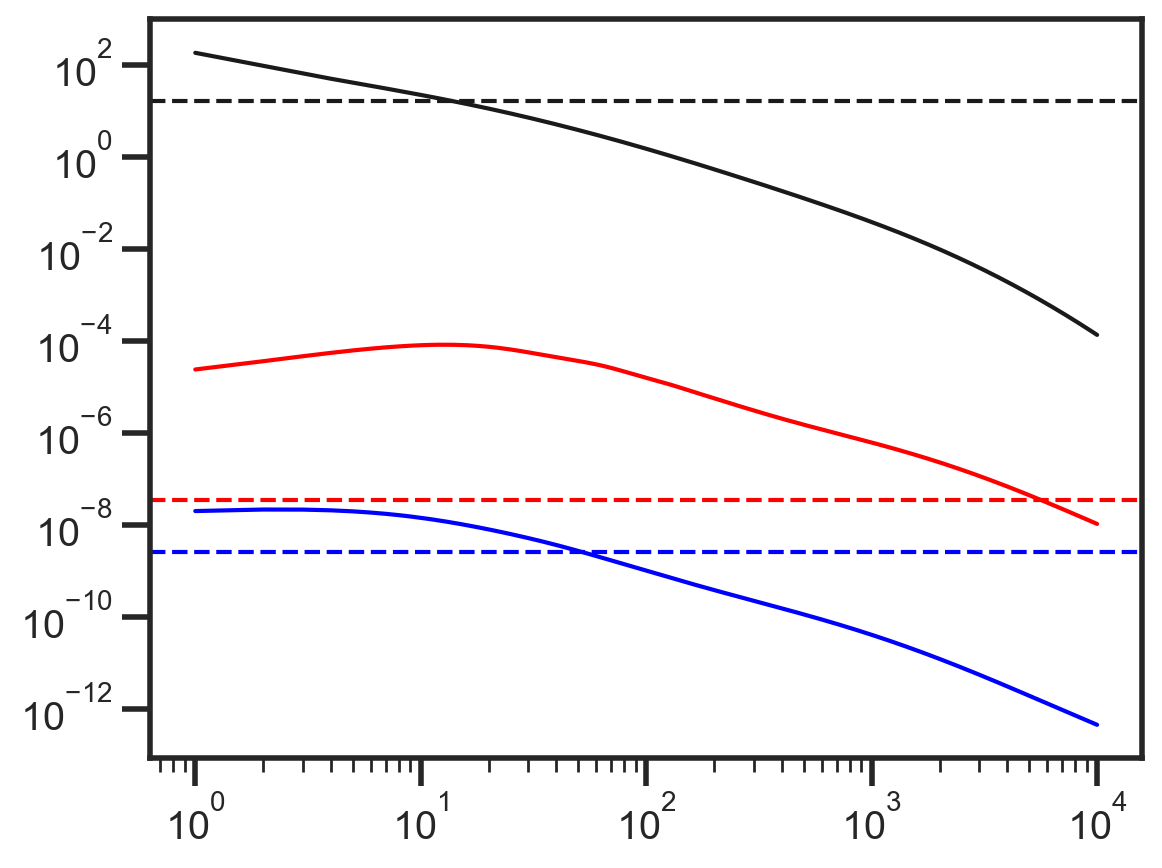

In [5]:
z_grid = src_dist.z_grid
chi_grid = src_dist.chi
Hz_grid = src_dist.Hz
logk_grid = np.log10(k_fields)
ells = np.arange(lmin, lmax + 1)


def Cell(W1, W2, z_P, P, b1=1, b2=1, z_grid=z_grid, chi_grid=chi_grid, Hz_grid=Hz_grid, logk_grid=logk_grid, ells=ells):
    """Compute angular power spectrum C_ell via Limber approximation."""
    pts_z = np.repeat(z_grid[None, :], len(ells), axis=0)
    k_grid = ((ells[:, None]+0.5) / chi_grid[None, :])
    pts_logk = np.log10(k_grid)
    
    pts_z = np.stack([pts_z.ravel(), pts_logk.ravel()], axis=-1)
    
    logP_interpolator = RegularGridInterpolator((z_P, np.log10(k_fields)), np.log10(P), bounds_error=False, fill_value=None)
    logP_vals = logP_interpolator(pts_z).reshape(len(ells), len(z_grid))
    
    Pk_values_Mpc3 = (10.0**logP_vals)*b1*b2
    integrand_z = (W1[None, :] * W2[None, :] / chi_grid[None, :]**2) * Pk_values_Mpc3 * (c / Hz_grid[None, :])
    return trapezoid(integrand_z, z_grid, axis=1)


z_P, P = precomputed_power_spectra("params_0", "gg")
C_ell_DD = Cell(src_dist.W_DM_wt, src_dist.W_DM_wt, z_P, P)

z_P, P = precomputed_power_spectra("params_0", "mm")
C_ell_kk = Cell(src_dist.W_k_wt1, src_dist.W_k_wt1, z_P, P)

z_P, P = precomputed_power_spectra("params_0", "mm")
C_ell_gg = Cell(src_dist.W_g_wt1, src_dist.W_g_wt1, z_P, P, b1=1.24, b2=1.24)

zmean_f = np.mean(np.random.choice(src_dist.z_grid, 10000, p=src_dist.dn2d_dz_frb/np.sum(src_dist.dn2d_dz_frb)))
DMhost_var = 100**2
sigma_e = 0.36769552621
    
var_DMfield = np.trapz(ells*C_ell_DD, ells)/(2*np.pi)
var_GALfield = np.trapz(ells*C_ell_gg, ells)/(2*np.pi)
var_KAPPAfield = np.trapz(ells*C_ell_kk, ells)/(2*np.pi)

N_DM = ((DMhost_var/((1+zmean_f)**2)) + (var_DMfield))/(src_dist.n2d_mean_frb)
N_g1 = (1+var_GALfield)/src_dist.n2d_mean_g1
N_k1 = ((sigma_e**2)/src_dist.n2d_mean_g2)/2

plt.loglog(ells, C_ell_kk, color="blue")
plt.axhline(N_k1, color="blue", ls="--")

plt.loglog(ells, C_ell_DD, color="k")
plt.axhline(N_DM, color="k", ls="--")

plt.loglog(ells, C_ell_gg, color="red")
plt.axhline(N_g1, color="red", ls="--")



In [6]:
def return_data_vectors(dir_idx):
    cosmo_calc = CosmologyCalculator(H0_kms_per_Mpc=100*df["h"][dir_idx], Ob0=df["Ob0"][dir_idx], 
                                     Om0=df["Om0"][dir_idx], sigma8=df["sigma8"][dir_idx], 
                                     m_nu=df["m_nu"][dir_idx], w0=df["w0"][dir_idx], wa=df["wa"][dir_idx])
    z_P, P_mm = precomputed_power_spectra("params_{}".format(dir_idx), "mm")
    z_P, P_gm = precomputed_power_spectra("params_{}".format(dir_idx), "gm"); P_gm[P_gm<0] = 1e-100
    z_P, P_gg = precomputed_power_spectra("params_{}".format(dir_idx), "gg")
    galaxy_bias = {1: 1.24, 2: 1.36, 3: 1.47, 4: 1.60, 5: 1.76}

    order = [11,21,31,41,51,22,32,42,52,33,43,53,44,54,55]

    shear_shear = {}
    for ij in order:
        zbin_idx1 = int((ij%100 - ij%10)/10)
        zbin_idx2 = ij%10
        src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
                                      zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_idx1, zbin_k_idx2=zbin_idx2, 
                                      zbin_g_idx1=zbin_g_idx1, zbin_g_idx2=zbin_g_idx2, 
                                      n2d_mean_frb=n2d_mean_frb, n2d_mean_g1=n2d_mean_g1, n2d_mean_g2=n2d_mean_g2)
        shear_shear[ij] = Cell(src_dist.W_k_wt1, src_dist.W_k_wt2, z_P, P_mm, chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)
        
    galaxy_galaxy = {}
    for ij in order:
        zbin_idx1 = int((ij%100 - ij%10)/10)
        zbin_idx2 = ij%10
        src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
                                      zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_k_idx1, zbin_k_idx2=zbin_k_idx2, 
                                      zbin_g_idx1=zbin_idx1, zbin_g_idx2=zbin_idx2, 
                                      n2d_mean_frb=n2d_mean_frb, n2d_mean_g1=n2d_mean_g1, n2d_mean_g2=n2d_mean_g2)
        galaxy_galaxy[ij] = Cell(src_dist.W_g_wt1, src_dist.W_g_wt2, z_P, P_mm, 
                                         b1=galaxy_bias[zbin_idx1], b2=galaxy_bias[zbin_idx2], chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)

    order = [11, 12, 13, 14, 15, 21, 22, 23, 24, 25, 31, 32, 33, 34, 35, 41, 42, 43, 44, 45, 51, 52, 53, 54, 55]

    shear_galaxy = {}
    for ij in order:
        zbin_idx1 = int((ij%100 - ij%10)/10)
        zbin_idx2 = ij%10
        src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
                                      zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_idx1, zbin_k_idx2=zbin_idx2, 
                                      zbin_g_idx1=zbin_idx2, zbin_g_idx2=zbin_idx2, 
                                      n2d_mean_frb=n2d_mean_frb, n2d_mean_g1=n2d_mean_g1, n2d_mean_g2=n2d_mean_g2)
        shear_galaxy[ij] = Cell(src_dist.W_k_wt1, src_dist.W_g_wt1, z_P, P_mm, 
                                         b1=1, b2=galaxy_bias[zbin_idx2], chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)

    order = [11, 22, 33, 44, 55]  
    
    DM_galaxy = {}
    for ij in order:
        zbin_idx1 = int((ij%100 - ij%10)/10)
        src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
                                      zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_k_idx1, zbin_k_idx2=zbin_k_idx2, 
                                      zbin_g_idx1=zbin_idx1, zbin_g_idx2=zbin_g_idx2, 
                                      n2d_mean_frb=n2d_mean_frb, n2d_mean_g1=n2d_mean_g1, n2d_mean_g2=n2d_mean_g2)
        DM_galaxy[ij] = Cell(src_dist.W_DM_wt, src_dist.W_g_wt1, z_P, P_gm, b1=galaxy_bias[zbin_idx1], chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)

    DM_shear = {}
    for ij in order:
        zbin_idx1 = int((ij%100 - ij%10)/10)
        src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
                                      zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_idx1, zbin_k_idx2=zbin_k_idx2, 
                                      zbin_g_idx1=zbin_g_idx1, zbin_g_idx2=zbin_g_idx2, 
                                      n2d_mean_frb=n2d_mean_frb, n2d_mean_g1=n2d_mean_g1, n2d_mean_g2=n2d_mean_g2)
        DM_shear[ij] = Cell(src_dist.W_DM_wt, src_dist.W_k_wt1, z_P, P_gm, chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)
        
    DM_DM = {}
    src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
                                  zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_k_idx1, zbin_k_idx2=zbin_k_idx2, 
                                  zbin_g_idx1=zbin_g_idx1, zbin_g_idx2=zbin_g_idx2, 
                                  n2d_mean_frb=n2d_mean_frb, n2d_mean_g1=n2d_mean_g1, n2d_mean_g2=n2d_mean_g2)
    DM_DM[0] = Cell(src_dist.W_DM_wt, src_dist.W_DM_wt, z_P, P_gg, chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)
    
    return {"shear_shear": shear_shear, 
            "galaxy_galaxy": galaxy_galaxy, 
            "shear_galaxy": shear_galaxy, 
            "DM_galaxy": DM_galaxy, 
            "DM_shear": DM_shear, 
            "DM_DM": DM_DM}


# def process_index(i):
#     data_vectors = return_data_vectors(i)
#     filename = f"data/forecasts/precomputed_data_vectors/data_vectors_{i}.npz"
#     np.savez_compressed(
#         filename,
#         shear_shear=data_vectors["shear_shear"],
#         galaxy_galaxy=data_vectors["galaxy_galaxy"],
#         shear_galaxy=data_vectors["shear_galaxy"],
#         DM_galaxy=data_vectors["DM_galaxy"],
#         DM_shear=data_vectors["DM_shear"],
#         DM_DM=data_vectors["DM_DM"]
#     )
#     return i

# results = Parallel(n_jobs=4)(
#     delayed(process_index)(i)
#     for i in tqdm(range(len(df)))
# )



In [7]:
def get_spectra_fields(dir_idx):
    data_vectors = np.load(f"data/forecasts/precomputed_data_vectors/data_vectors_{dir_idx}.npz", allow_pickle=True)
    spectra = []
    fields = []
    tracers = []
 
    # Shear-Shear: key ij -> kappa bin i, kappa bin j
    for key in sorted(data_vectors["shear_shear"].item().keys()):
        b1, b2 = _bins_from_key(key)
        spectra.append(data_vectors["shear_shear"].item()[key])
        fields.append(("k", "k"))
        tracers.append(("k", b1, "k", b2))
 
    # Galaxy-Galaxy: key ij -> galaxy bin i, galaxy bin j
    for key in sorted(data_vectors["galaxy_galaxy"].item().keys()):
        b1, b2 = _bins_from_key(key)
        spectra.append(data_vectors["galaxy_galaxy"].item()[key])
        fields.append(("g", "g"))
        tracers.append(("g", b1, "g", b2))
 
    # Shear-Galaxy: key ij -> kappa bin i, galaxy bin j
    for key in sorted(data_vectors["shear_galaxy"].item().keys()):
        b1, b2 = _bins_from_key(key)
        spectra.append(data_vectors["shear_galaxy"].item()[key])
        fields.append(("k", "g"))
        tracers.append(("k", b1, "g", b2))
 
    # DM-Galaxy: key ij is diagonal (i==j); D is a single non-tomographic
    # field, so we give it a fixed dummy bin index 0.
    for key in sorted(data_vectors["DM_galaxy"].item().keys()):
        b1, _ = _bins_from_key(key)
        spectra.append(data_vectors["DM_galaxy"].item()[key])
        fields.append(("D", "g"))
        tracers.append(("D", 0, "g", b1))
 
    # DM-Shear
    for key in sorted(data_vectors["DM_shear"].item().keys()):
        b1, _ = _bins_from_key(key)
        spectra.append(data_vectors["DM_shear"].item()[key])
        fields.append(("D", "k"))
        tracers.append(("D", 0, "k", b1))
 
    # DM-DM: single non-tomographic auto-spectrum
    for key in sorted(data_vectors["DM_DM"].item().keys()):
        spectra.append(data_vectors["DM_DM"].item()[key])
        fields.append(("D", "D"))
        tracers.append(("D", 0, "D", 0))
 
    return np.array(spectra), np.array(fields), tracers


In [8]:
def _bins_from_key(ij):
    b1 = int((ij % 100 - ij % 10) / 10)
    b2 = ij % 10
    return b1, b2

def gaussian_covariance_blocks(
        dir_idx,
        f_sky,
        N_g,
        N_k,
        N_DM):
    
    spectra, fields, tracers = get_spectra_fields(dir_idx)
    n_spec, n_ell = spectra.shape
 
    Chat = spectra.copy()
 
    for i, (A, binA, B, binB) in enumerate(tracers):
        if A == B and binA == binB:
            if A == "g":
                Chat[i] += N_g
            elif A == "k":
                Chat[i] += N_k
            elif A == "D":
                Chat[i] += N_DM
 
    C_lookup = {}
    for i, (A, binA, B, binB) in enumerate(tracers):
        C_lookup[(A, binA, B, binB)] = Chat[i]
        C_lookup[(B, binB, A, binA)] = Chat[i]  # symmetry
 
    def get_C(X, xbin, Y, ybin):
        key = (X, xbin, Y, ybin)
        if key in C_lookup:
            return C_lookup[key]
        return np.zeros(n_ell)
 
    cov_blocks = np.zeros((n_ell, n_spec, n_spec))
    prefac = 1.0 / ((2 * ells + 1) * f_sky)  # shape (n_ell,)
 
    for a in tqdm(range(n_spec)):
        A, binA, B, binB = tracers[a]
        for b in range(a, n_spec):
            C, binC, D, binD = tracers[b]
 
            term1 = get_C(A, binA, C, binC) * get_C(B, binB, D, binD)
            term2 = get_C(A, binA, D, binD) * get_C(B, binB, C, binC)
 
            cov_ab = prefac * (term1 + term2)  # shape (n_ell,)
 
            cov_blocks[:, a, b] = cov_ab
            cov_blocks[:, b, a] = cov_ab
 
    return cov_blocks
    

# cov_blocks = gaussian_covariance_blocks(0, 0.4, N_g1, N_k1, N_DM)
# np.savez_compressed(
#         "data/forecasts/cov_blocks_1e4FRBs.npz",
#         cov_blocks=cov_blocks
#     )
cov_blocks = np.load("data/forecasts/cov_blocks_1e4FRBs.npz", allow_pickle=True)["cov_blocks"]


In [9]:
dC_dp = {}
for i, param in enumerate(param_names):
    dp = param_ranges[param][1]-param_ranges[param][0]
    spectra1, _, _ = get_spectra_fields((2*i)+1)
    spectra2, fields, tracers = get_spectra_fields(2*(i+1))
    dC_dp[param] = (spectra2-spectra1)/dp


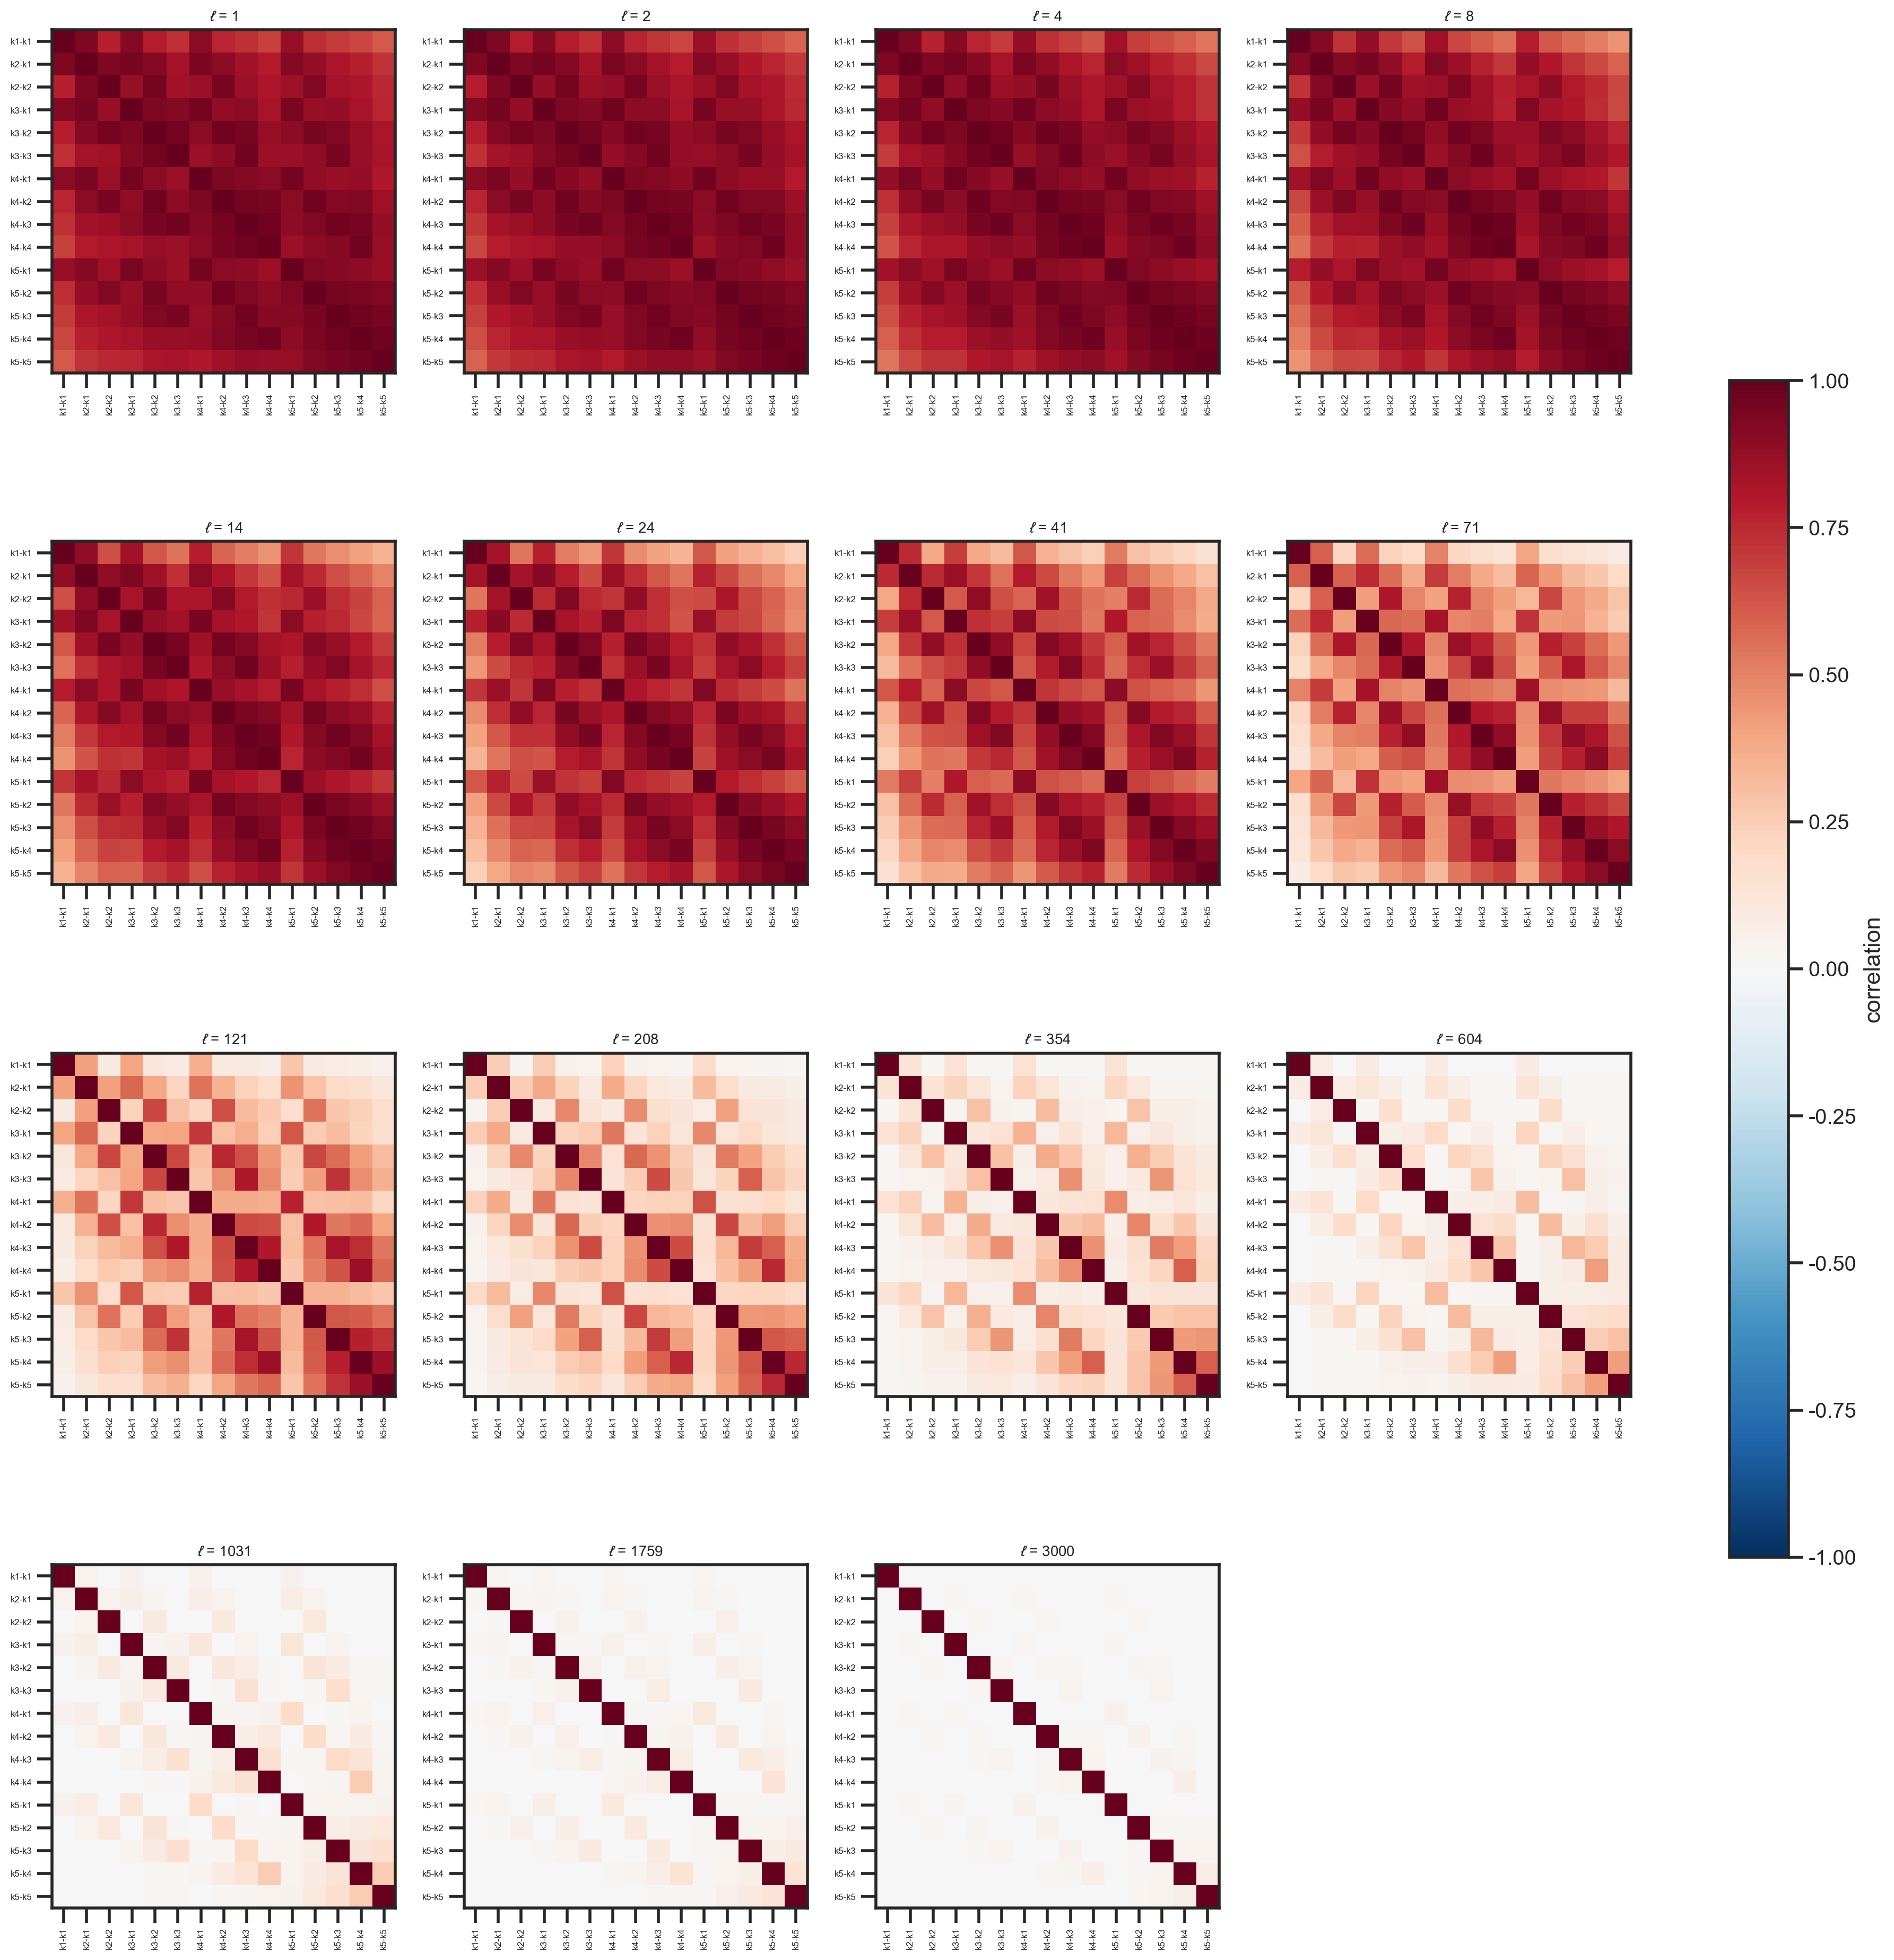

In [10]:
lmax_to_keep = 3000

def cov_to_corr(cov):
    d = np.sqrt(np.diag(cov))
    d[d == 0] = 1.0
    return cov / np.outer(d, d)

# mask out any tracer pair involving the DM field "D"
mask_3x2a = np.array([not ("D" in (A, B)) for (A, _, B, _) in tracers])
mask_3x2b = np.array([not ("g" in (A, B)) for (A, _, B, _) in tracers])
mask_3x2 = np.logical_and(mask_3x2a, mask_3x2b)

# build labels like "k1-k2" for the surviving (shear-shear only) tracer pairs
spec_labels_3x2 = [f"{A}{binA}-{B}{binB}" for (A, binA, B, binB), keep in zip(tracers, mask_3x2) if keep]

# sweep across many ell values, log-spaced so you see low-ell and high-ell behavior
ell_values = np.unique(np.geomspace(lmin, lmax_to_keep, 16).astype(int))
ell_indices = ell_values - lmin

ncols = 4
nrows = int(np.ceil(len(ell_values) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 6*nrows))
axes = axes.flatten()

for ax, ell_idx, ell in zip(axes, ell_indices, ell_values):
    cov_3x2 = cov_blocks[ell_idx][np.ix_(mask_3x2, mask_3x2)]
    corr = cov_to_corr(cov_3x2)
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r", origin='upper')
    ax.set_title(f"$\\ell$ = {ell}", fontsize=10)

    ax.set_xticks(range(len(spec_labels_3x2)))
    ax.set_xticklabels(spec_labels_3x2, rotation=90, fontsize=6)
    ax.set_yticks(range(len(spec_labels_3x2)))
    ax.set_yticklabels(spec_labels_3x2, fontsize=6)

# hide any unused panels
for ax in axes[len(ell_values):]:
    ax.axis("off")

fig.colorbar(im, ax=axes.tolist(), shrink=0.6, label="correlation")
plt.show()